In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from wordcloud import WordCloud
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:/XYZ/SEntFiN-v1.1.csv")

In [3]:
data.shape

(10753, 4)

In [4]:
data.head(5)

,S No.,Title,Decisions,Words
0,1,SpiceJet to issue 6.4 crore warrants to promoters,"{""SpiceJet"": ""neutral""}",8
1,2,MMTC Q2 net loss at Rs 10.4 crore,"{""MMTC"": ""neutral""}",8
2,3,"Mid-cap funds can deliver more, stay put: Experts","{""Mid-cap funds"": ""positive""}",8
3,4,Mid caps now turn into market darlings,"{""Mid caps"": ""positive""}",7
4,5,"Market seeing patience, if not conviction: Pra...","{""Market"": ""neutral""}",8


In [5]:
data.columns

Index(['S No.', 'Title', 'Decisions', 'Words'], dtype='object')

In [6]:
print(data['Decisions'].value_counts(normalize=True))

Decisions
{"Sebi": "neutral"}                                           0.017576
{"Nifty": "neutral"}                                          0.013578
{"Nifty": "positive"}                                         0.005487
{"Sensex": "negative"}                                        0.004836
{"Gold": "negative"}                                          0.004371
                                                                ...   
{"Greenply": "negative"}                                      0.000093
{"Glencore": "negative", "global commodities": "negative"}    0.000093
{"agriculture commodities": "negative"}                       0.000093
{"Fortis": "neutral"}                                         0.000093
{"Australia shares": "neutral", "energy": "neutral"}          0.000093
Name: proportion, Length: 6564, dtype: float64


In [7]:
print("Sample decision column")
print(data['Decisions'].iloc[0])
print("\nType of decision column:", type(data['Decisions'].iloc[0]))

Sample decision column
{"SpiceJet": "neutral"}

Type of decision column: <class 'str'>


In [8]:
# lets try to parse it
import ast
try:
    example = ast.literal_eval(data['Decisions'].iloc[0])
    print("Parsed successfully:", example)
except Exception as e:
    print("Parsing error:", e)

Parsed successfully: {'SpiceJet': 'neutral'}


In [9]:
# Expanding the data
expanded_rows =[]
for idx, row in data.iterrows():
    headline = row['Title']
    decisions_str = row['Decisions']
    try:
        # parsing decisions
        if isinstance(decisions_str, str):
            decisions= ast.literal_eval(decisions_str)
        else:
            decisions = decisions_str

        for entity, sentiment in decisions.items():
            expanded_rows.append({
                'headline': headline,
                'entity': entity.strip(),
                'sentiment': sentiment.lower() if isinstance(sentiment, str) else sentiment,
                'original_index': idx
            })
    except:
        # skip probleamtic rows or log them
        continue
        

In [10]:
expanded_data = pd.DataFrame(expanded_rows)
print(f"\nExpanded Dataset Shape: {expanded_data.shape}")


Expanded Dataset Shape: (14409, 4)


# EDA

In [11]:
expanded_df = expanded_data.copy()
print(f"Total Entity-level samples:{expanded_df.shape[0]}")
print(f"Total Unique Headlines: {expanded_df['headline'].nunique()}")

Total Entity-level samples:14409
Total Unique Headlines: 10686



1. Sentiment Distribution
sentiment
neutral     5515
positive    5075
negative    3819
Name: count, dtype: int64
sentiment
neutral     38.274689
positive    35.221042
negative    26.504268
Name: proportion, dtype: float64


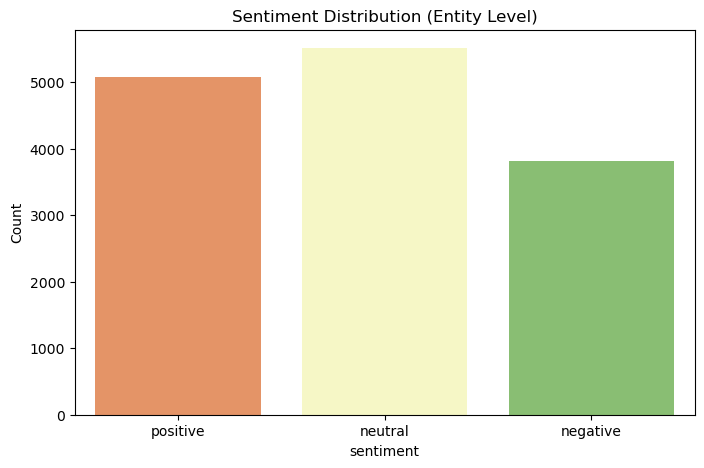

In [12]:
# Sentiment Distribution
print("\n1. Sentiment Distribution")
print(expanded_df['sentiment'].value_counts())
print(expanded_df['sentiment'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=expanded_df, x='sentiment', 
              palette='RdYlGn', 
              order=['positive', 'neutral', 'negative'])
plt.title('Sentiment Distribution (Entity Level)')
plt.ylabel('Count')
plt.show()


2. Multi-Entity Analysis
Headlines with multiple entities: 2889
Headlines with conflicting sentiments: 1237


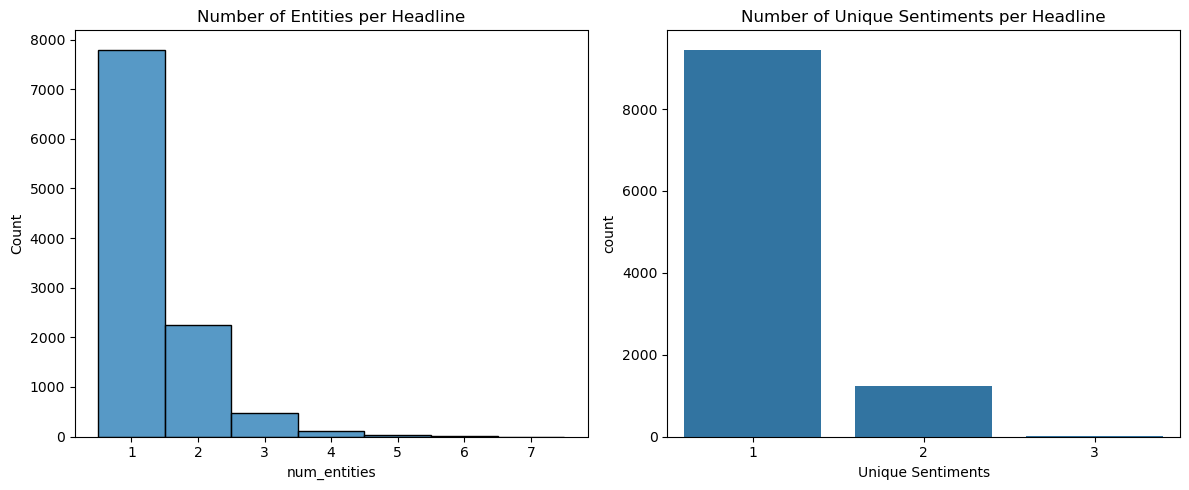

In [13]:
# Multi-Entity & Conflict Analysis
headline_stats = expanded_df.groupby('headline').agg(
    num_entities=('entity', 'count'),
    unique_sentiments=('sentiment', 'nunique')
).reset_index()

print(f"\n2. Multi-Entity Analysis")
print(f"Headlines with multiple entities: {len(headline_stats[headline_stats['num_entities'] > 1])}")
print(f"Headlines with conflicting sentiments: {len(headline_stats[headline_stats['unique_sentiments'] > 1])}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(headline_stats['num_entities'], bins=range(1, 8), discrete=True)
plt.title('Number of Entities per Headline')

plt.subplot(1, 2, 2)
sns.countplot(data=headline_stats, x='unique_sentiments')
plt.title('Number of Unique Sentiments per Headline')
plt.xlabel('Unique Sentiments')
plt.tight_layout()
plt.show()

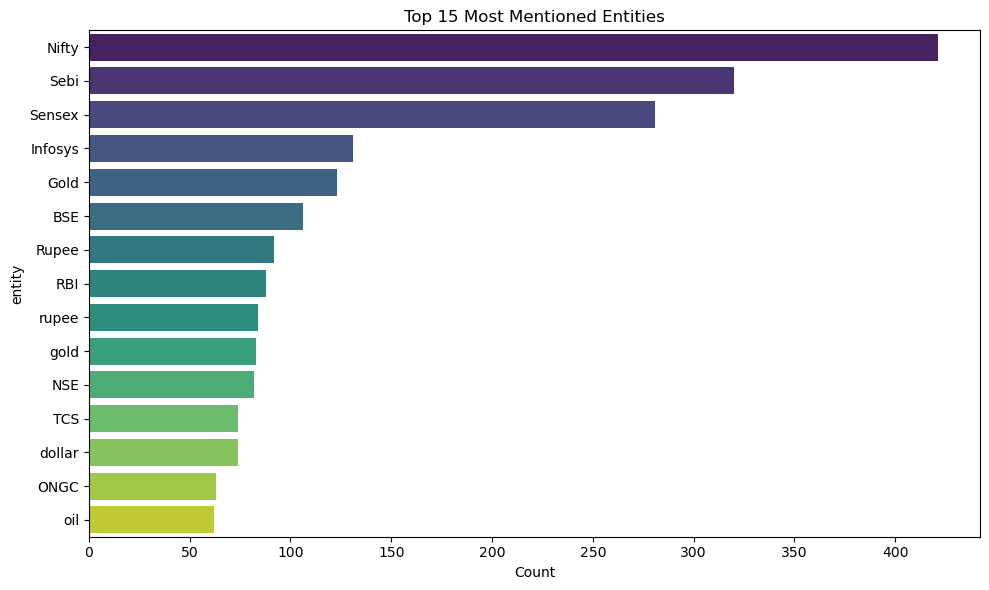

In [14]:
# Top Entities
plt.figure(figsize=(10, 6))
top_entities = expanded_df['entity'].value_counts().head(15)
sns.barplot(x=top_entities.values, y=top_entities.index, palette='viridis')
plt.title('Top 15 Most Mentioned Entities')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

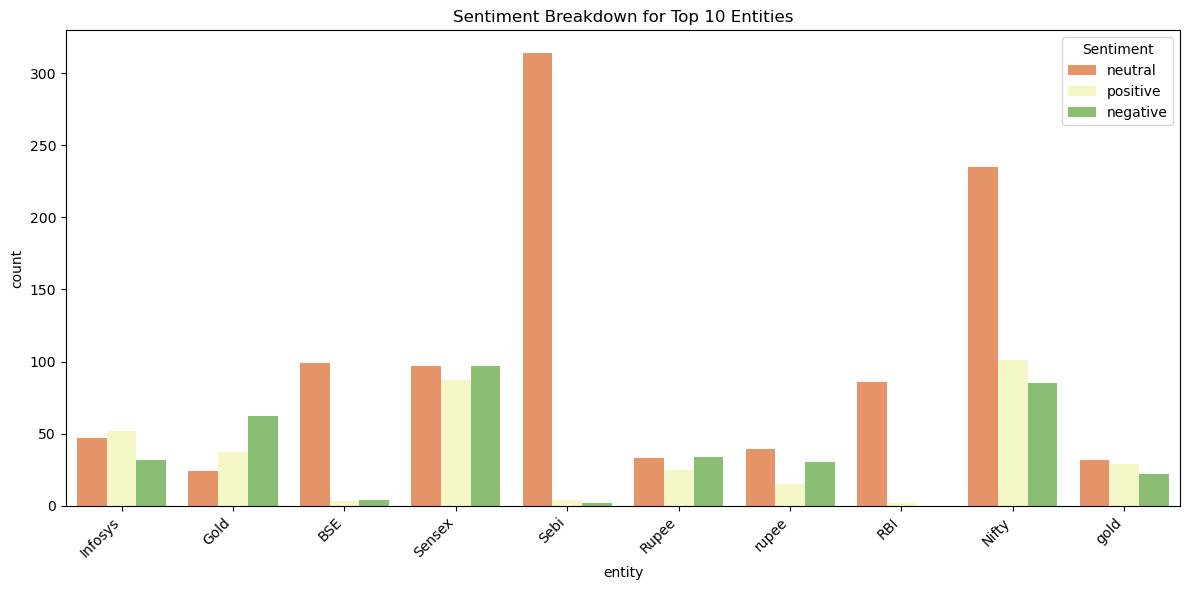

In [15]:
# Sentiment Distribution for Top Entities
top_10 = top_entities.head(10).index
plt.figure(figsize=(12, 6))
sns.countplot(data=expanded_df[expanded_df['entity'].isin(top_10)], 
              x='entity', hue='sentiment', palette='RdYlGn')
plt.title('Sentiment Breakdown for Top 10 Entities')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

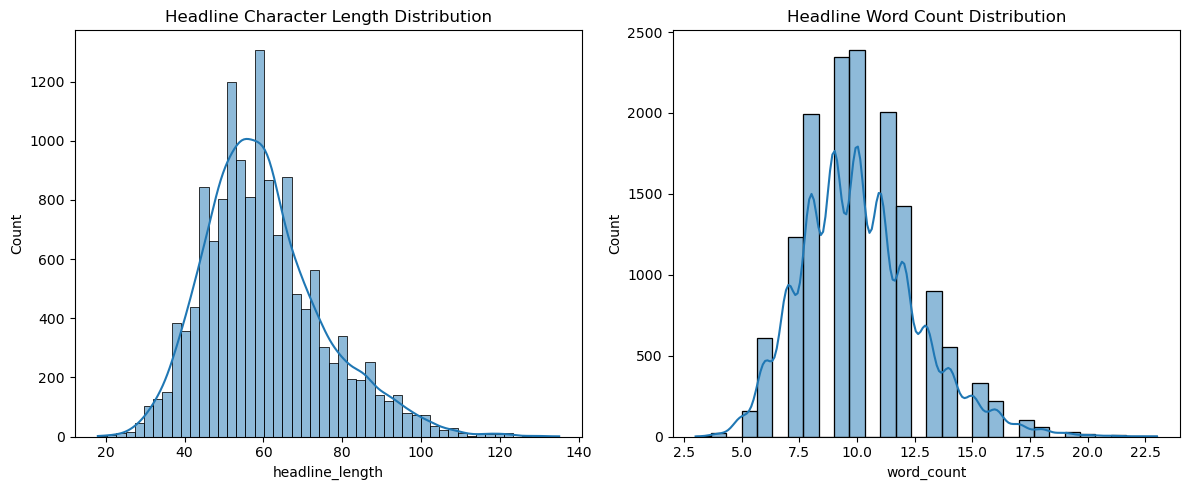

In [16]:
# 5. Headline Length Analysis
expanded_df['headline_length'] = expanded_df['headline'].str.len()
expanded_df['word_count'] = expanded_df['headline'].str.split().str.len()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(expanded_df['headline_length'], bins=50, kde=True)
plt.title('Headline Character Length Distribution')

plt.subplot(1, 2, 2)
sns.histplot(expanded_df['word_count'], bins=30, kde=True)
plt.title('Headline Word Count Distribution')
plt.tight_layout()
plt.show()


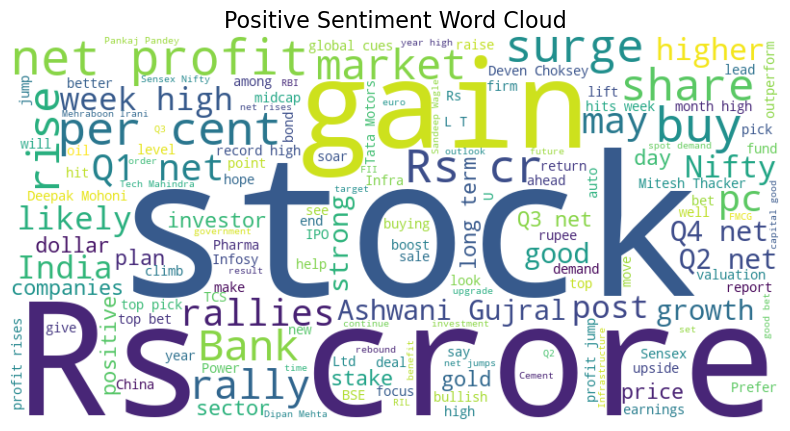

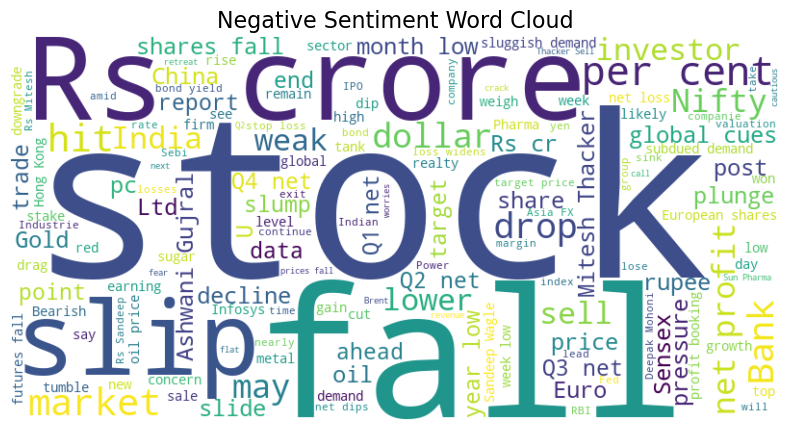

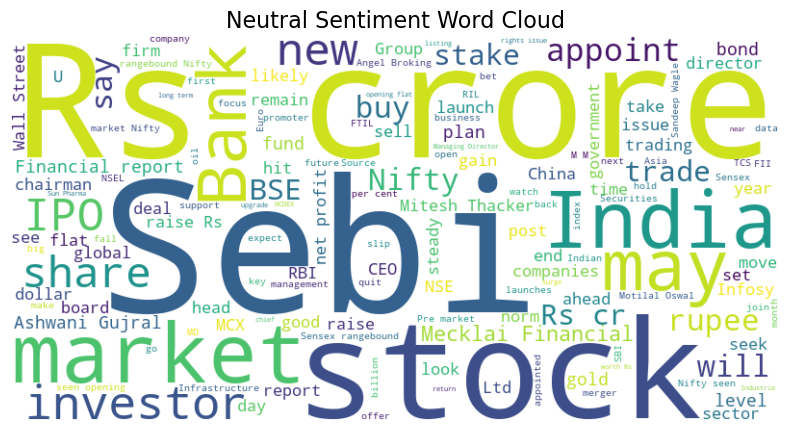

In [17]:
# Word Clouds
def plot_wordcloud(sentiment_label, title):
    text = " ".join(expanded_df[expanded_df['sentiment'] == sentiment_label]['headline'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                         colormap='viridis', max_words=150).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

plot_wordcloud('positive', 'Positive Sentiment Word Cloud')
plot_wordcloud('negative', 'Negative Sentiment Word Cloud')
plot_wordcloud('neutral', 'Neutral Sentiment Word Cloud')

# Preprocessing & Feature Engineering

In [18]:
import re
# Basic cleaning
def clean_headline(text):
    """ Clean the headline text """
    text = str(text)
    # to remove URLs
    text = re.sub(r'http\S+|www\S', '', text)
    # to keep only useful characters
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'"()-]', ' ', text)
    # to remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()
expanded_df['clean_headline'] = expanded_df['headline'].apply(clean_headline)

In [19]:
# Entity Normalization (Important for finacial entities)
def normalize_entity(entity):
    entity = str(entity).strip().lower()
    # common financila entity normalizations
    mappings = {
        'ril': 'reliance',
        'tcs': 'tcs',
        'hdfcbank': 'hdfc bank',
        'sbin': 'state bank of india',
        'icicibank': 'icici bank',
    }
    return mappings.get(entity, entity)
expanded_df['normalized_entity'] = expanded_df['entity'].apply(normalize_entity)

In [20]:
# creating model input (most import for ABSA)
def create_model_input(row):
    """Create input format suitable for transformers"""
    headline = row['clean_headline']
    entity = row['entity']
    # best format for entity-aware sentiment
    return f"[CLS] {headline} [SEP] {entity} [SEP]"
expanded_df['model_input'] = expanded_df.apply(create_model_input, axis=1)

In [21]:
# label encoding
label_map = {'positive':2, 'nuetral':1, 'negative': 0}
expanded_df['label'] = expanded_df['sentiment'].map(label_map)
# checking for any unmapped labels
print("Unmapped sentiments:", expanded_df['sentiment'][expanded_df['label'].isnull()].unique())

Unmapped sentiments: ['neutral']


In [22]:
# training / validation/ test split)
from sklearn.model_selection import train_test_split
# Split by unique headlines to prevent leakage
unique_headlines = expanded_df['headline'].unique()
train_headlines, temp_headlines = train_test_split(unique_headlines, test_size=0.3, random_state=42)
val_headlines, test_headlines = train_test_split(temp_headlines, test_size=0.5, random_state=42)

train_df = expanded_df[expanded_df['headline'].isin(train_headlines)]
val_df = expanded_df[expanded_df['headline'].isin(val_headlines)]
test_df = expanded_df[expanded_df['headline'].isin(test_headlines)]

print(f"Train Shape : {train_df.shape}")
print(f"Validation Shape: {val_df.shape}")
print(f"Test Shape : {test_df.shape}")



Train Shape : (10091, 10)
Validation Shape: (2163, 10)
Test Shape : (2155, 10)


In [23]:
# Saving Processed Dataset
train_df.to_csv("sentfin_train.csv", index=False)
val_df.to_csv("sentfin_val.csv", index=False)
test_df.to_csv("sentfin_test.csv", index=False)

print("\nPreprocessing Completed and Files Saved!")
print("Final Columns:", train_df.columns.tolist())
print("\nSample Model Input:")
print(train_df['model_input'].iloc[0])
print("\nLabel Distribution in Train:")
print(train_df['sentiment'].value_counts(normalize=True))


Preprocessing Completed and Files Saved!
Final Columns: ['headline', 'entity', 'sentiment', 'original_index', 'headline_length', 'word_count', 'clean_headline', 'normalized_entity', 'model_input', 'label']

Sample Model Input:
[CLS] mmtc q2 net loss at rs 10.4 crore [SEP] MMTC [SEP]

Label Distribution in Train:
sentiment
neutral     0.380834
positive    0.352393
negative    0.266772
Name: proportion, dtype: float64


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

In [25]:
# loading data
train_df = pd.read_csv("sentfin_train.csv")
val_df = pd.read_csv("sentfin_val.csv")
test_df = pd.read_csv("sentfin_test.csv")

In [26]:
print("Before cleaning:")
print("Train NaNs in sentiment:", train_df['sentiment'].isnull().sum())
print(train_df['sentiment'].value_counts(dropna=False))

# Clean sentiment column
for df in [train_df, val_df, test_df]:
    df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
    
    # Fix any unexpected values (safety net)
    df['sentiment'] = df['sentiment'].replace({
        'pos': 'positive',
        'neg': 'negative',
        'neu': 'neutral'
    })

# Re-create label
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}

for df in [train_df, val_df, test_df]:
    df['label'] = df['sentiment'].map(label_map)

# Check for remaining NaNs
print("\nAfter cleaning - NaNs in label:")
print("Train:", train_df['label'].isnull().sum())
print("Val:", val_df['label'].isnull().sum())
print("Test:", test_df['label'].isnull().sum())

# Drop rows with NaN labels (if any remain)
train_df = train_df.dropna(subset=['label'])
val_df = val_df.dropna(subset=['label'])
test_df = test_df.dropna(subset=['label'])

print(f"Final Train Shape after cleaning: {train_df.shape}")

Before cleaning:
Train NaNs in sentiment: 0
sentiment
neutral     3843
positive    3556
negative    2692
Name: count, dtype: int64

After cleaning - NaNs in label:
Train: 0
Val: 0
Test: 0
Final Train Shape after cleaning: (10091, 10)


In [27]:
#TF=IDF Vectorization
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words='english')
X_train = vectorizer.fit_transform(train_df['model_input'])
X_val = vectorizer.fit_transform(val_df['model_input'])
X_test = vectorizer.fit_transform(test_df['model_input'])

y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "SVM (Linear)": LinearSVC(class_weight='balanced', random_state=42, max_iter=2000),
    "XGBoost": XGBClassifier(n_stimators=300, learning_rates=0.1, max_depths=6, eval_metric='mlogloss',
                             random_state=42, use_label_encoder=False)
}
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    # validate
    val_pred = model.predict(X_val)
    print(f"n {name} - Validation Results - ")
    print(classification_report(y_val, val_pred,
                                target_names=['Negative', 'Nuetral', 'Positive']))
    results[name] = {
        'model': model,
        'val_f1': classification_report(y_val, val_pred, output_dict=True)['macro avg']['f1-score']
    }
                             

Training Logistic Regression...
n Logistic Regression - Validation Results - 
              precision    recall  f1-score   support

    Negative       0.25      0.12      0.16       538
     Nuetral       0.40      0.56      0.46       872
    Positive       0.38      0.35      0.36       753

    accuracy                           0.38      2163
   macro avg       0.34      0.34      0.33      2163
weighted avg       0.36      0.38      0.35      2163

Training SVM (Linear)...
n SVM (Linear) - Validation Results - 
              precision    recall  f1-score   support

    Negative       0.26      0.17      0.20       538
     Nuetral       0.39      0.56      0.46       872
    Positive       0.37      0.29      0.32       753

    accuracy                           0.36      2163
   macro avg       0.34      0.34      0.33      2163
weighted avg       0.35      0.36      0.35      2163

Training XGBoost...
n XGBoost - Validation Results - 
              precision    recall  f1-scor

In [29]:
# picking the best model
best_model_name = max(results, key=lambda x: results[x]['val_f1'])
best_model = results[best_model_name]['model']
best_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
# predictions
test_pred = best_model.predict(X_test)
print(classification_report(y_test, test_pred, target_names=['Negative', 'Neutral', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.28      0.14      0.18       589
     Neutral       0.39      0.48      0.43       800
    Positive       0.36      0.41      0.39       766

    accuracy                           0.36      2155
   macro avg       0.34      0.34      0.33      2155
weighted avg       0.35      0.36      0.35      2155



<function matplotlib.pyplot.show(close=None, block=None)>

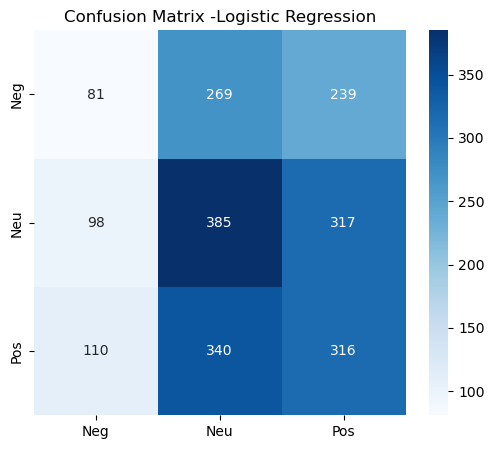

In [31]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot = True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'])
plt.title(f'Confusion Matrix -{best_model_name}')
plt.show

# Deeplearning - FinBERT

In [32]:
!pip install datasets transformers scikit-learn torch
!pip install transformers[torch]
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

In [33]:
!pip uninstall accelerate -y

Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0


In [34]:
!pip install accelerate>=0.26.0 transformers[torch] -U

In [35]:
print("Train_shape:", train_df.shape)
print("Label distribution in train:\n", train_df['sentiment'].value_counts()) 

Train_shape: (10091, 10)
Label distribution in train:
 sentiment
neutral     3843
positive    3556
negative    2692
Name: count, dtype: int64


In [36]:
# convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [37]:
# Tokenization
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_function(examples):
    return tokenizer(examples['model_input'],
                     padding='max_length',
                     truncation=True,
                     max_length=128)
print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Tokenizing data...


Map:   0%|          | 0/10091 [00:00<?, ? examples/s]

Map:   0%|          | 0/2163 [00:00<?, ? examples/s]

Map:   0%|          | 0/2155 [00:00<?, ? examples/s]

In [ ]:
# loading model & training
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)
training_args = TrainingArguments(
    output_dir="./finbert_sentfin_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=False,
    seed=42,
    report_to="none"
)

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, prediction),
        "f1_macro": f1_score(labels, predictions, average='macro'),
    }
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)
trainer.train()    

In [ ]:
# Evalution
print("\nEvaluating on Test set")
test_results = trainer.evalute(tokenized_test)
test_results
predictions_output = trainer.predict(tokenized_test)
pred = np.argmax(predictions_output,predictions, axis=1)
print("\n FinBERT Final Test Report ")
print(classifcation_report(predictions_output.label_ids, preds,
                           target_names=['Negative', 'Neutral', 'Positive']))